In [3]:
from gsw_teos10_implementation import * 
filepath_mean = '/lustre/storeB/project/fou/hi/foccus/datasets/norkystv3_averages'
checkpoint_mai_mean = 'norkyst800-202405_avg.nc'
import xarray as xr 

In [4]:
from dataloader import open_dataset

In [19]:
oslofjorden = open_dataset(f'{filepath_mean}/{checkpoint_mai_mean}', region = 'oslofjorden').ds
sulafjorden = open_dataset(f'{filepath_mean}/{checkpoint_mai_mean}', region = 'sulafjorden').ds

/lustre/storeB/project/fou/hi/foccus/malene/ocean-ai/plot/analysis/dataloader.py:32: FutureWarning: Setting attribute 'ds' on a 'open_dataset' object. Explicitly define __slots__ to suppress this warning for legitimate custom attributes and raise an error when attempting variables assignments.
  self.ds = xr.open_dataset(file)
/lustre/storeB/project/fou/hi/foccus/malene/ocean-ai/plot/analysis/dataloader.py:34: FutureWarning: Setting attribute 'depth' on a 'open_dataset' object. Explicitly define __slots__ to suppress this warning for legitimate custom attributes and raise an error when attempting variables assignments.
  self.depth=depth
/lustre/storeB/project/fou/hi/foccus/malene/ocean-ai/plot/analysis/dataloader.py:35: FutureWarning: Setting attribute 'region' on a 'open_dataset' object. Explicitly define __slots__ to suppress this warning for legitimate custom attributes and raise an error when attempting variables assignments.
  self.region=region
/lustre/storeB/project/fou/hi/focc

In [20]:
#OSLO

salinity_osl = oslofjorden.salinity.values
temperature_osl = oslofjorden.temperature.values

eta_target_osl, _ = entropy(SA = salinity_osl, Theta= temperature_osl)
density_field_osl, density_field_avg_amomaly = density_field(SA = salinity_osl, entropy_tar= eta_target_osl)


#SULAFJORDEN
salinity_sul = sulafjorden.salinity.values
temperature_sul = sulafjorden.temperature.values

eta_target_sul, _ = entropy(SA = salinity_sul, Theta= temperature_sul)
density_field_sul, density_field_avg_amomaly = density_field(SA = salinity_sul, entropy_tar= eta_target_sul)

theta = [[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]], h0 = [[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]], Theta = [[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]
[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]
s = [[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]], tau = [[nan 

In [26]:
import gsw 
"""OSLO"""
density_avg_gsw_osl = gsw.sigma0(salinity_osl, temperature_osl)
density_avg_gsw_osl += 1000
"""SULAFJORDEN"""
density_avg_gsw_sul = gsw.sigma0(salinity_sul, temperature_sul)
density_avg_gsw_sul += 1000

In [23]:
import matplotlib.pyplot as plt
import cartopy
import cmocean #using haline cmocean color 
import cartopy.crs as ccrs #cartopy north stereo

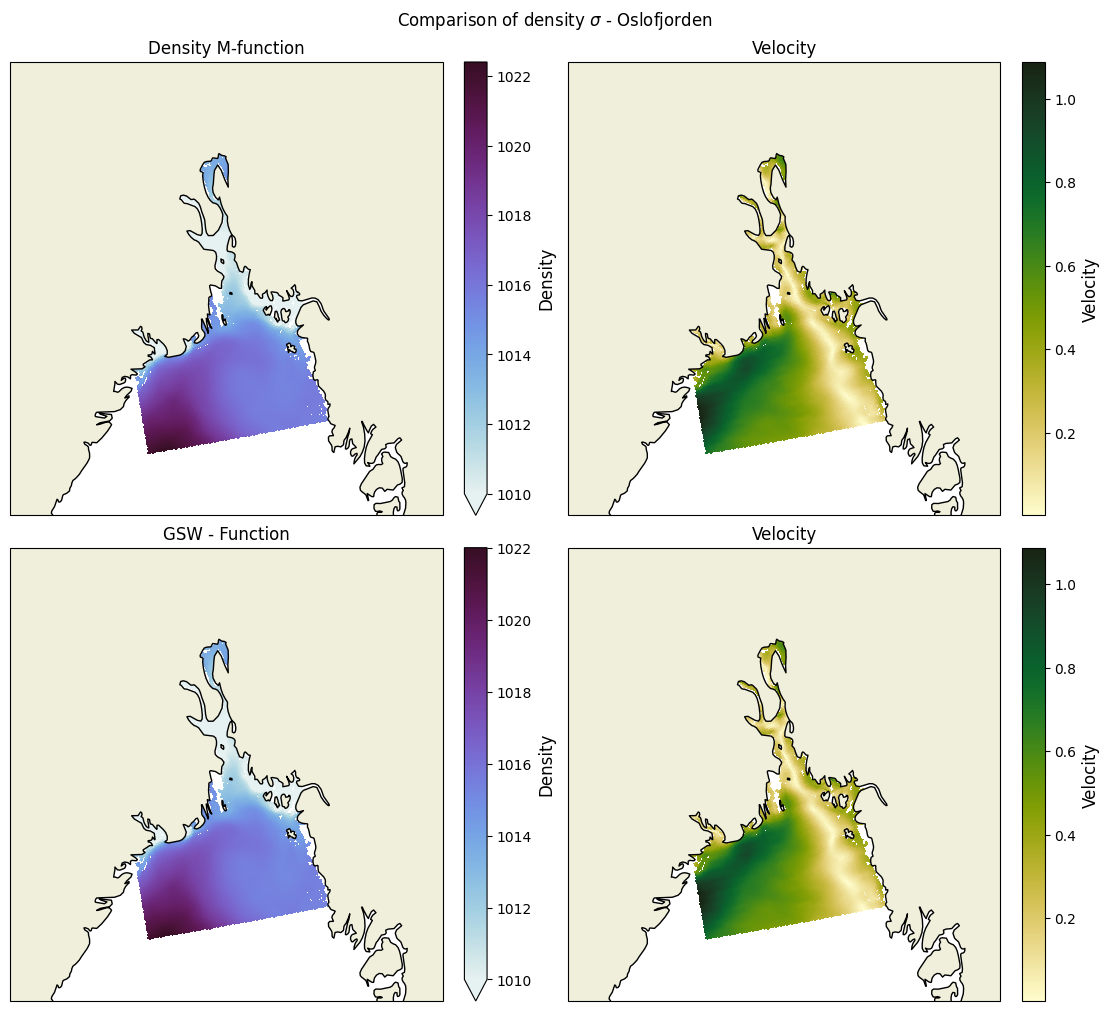

In [36]:
#Make plot of Skagerak + of northerner areas to examine whether the field looks plausible or not and compared to velocity field (focusing on fronts)

"""OSLO"""

fig, axes = plt.subplots(2,2, figsize = (12, 10), layout = 'compressed', subplot_kw= {'projection' : ccrs.NorthPolarStereo()})

#Own function
my_density = axes[0][0]
im1 = my_density.pcolormesh(oslofjorden.lon,oslofjorden.lat, density_field_osl, cmap = cmocean.cm.dense, transform = ccrs.PlateCarree(), vmin = 1010)
my_density.set_title(f'Density M-function') 
my_density.add_feature(cartopy.feature.LAND, zorder = 1, edgecolor = "black")
cbar1 = fig.colorbar(im1, ax=my_density, orientation = 'vertical', extend = 'min')
cbar1.set_label('Density', fontsize = 12)

#GSW function
norkyst_velocity = axes[0][1]
u,v =oslofjorden['u_eastward'].values,oslofjorden['Vwind_northward'].values
mean_vel = np.sqrt(u**2 + v**2)
im2 = norkyst_velocity.pcolormesh(oslofjorden.lon,oslofjorden.lat, mean_vel , cmap = cmocean.cm.speed, transform = ccrs.PlateCarree())
norkyst_velocity.set_title(f'Velocity') 
norkyst_velocity.add_feature(cartopy.feature.LAND, zorder = 1, edgecolor = "black")
cbar2 = fig.colorbar(im2, ax=norkyst_velocity, orientation = 'vertical')
cbar2.set_label('Velocity', fontsize = 12)

#diff
gsw_density = axes[1][0]
im3 = gsw_density.pcolormesh(oslofjorden.lon,oslofjorden.lat, density_avg_gsw_osl, cmap = cmocean.cm.dense, transform = ccrs.PlateCarree(), vmin = 1010)
gsw_density.set_title(f'GSW - Function') 
gsw_density.add_feature(cartopy.feature.LAND, zorder = 1, edgecolor = "black")
cbar2 = fig.colorbar(im3, ax=gsw_density, orientation = 'vertical', extend = 'min')
cbar2.set_label('Density', fontsize = 12)

#diff
norkyst_velocity2 = axes[1][1]
im4 = norkyst_velocity2.pcolormesh(oslofjorden.lon,oslofjorden.lat, mean_vel, cmap = cmocean.cm.speed, transform = ccrs.PlateCarree())
norkyst_velocity2.set_title(f'Velocity') 
norkyst_velocity2.add_feature(cartopy.feature.LAND, zorder = 1, edgecolor = "black")
cbar2 = fig.colorbar(im4, ax=norkyst_velocity2, orientation = 'vertical')
cbar2.set_label('Velocity', fontsize = 12)

for ax in [my_density, norkyst_velocity, gsw_density, norkyst_velocity2]:
    ax.set_ylabel('Latitude')
    ax.set_xlabel('Longitude')
    
plt.suptitle(r'Comparison of density $\sigma$ - Oslofjorden')
plt.show()


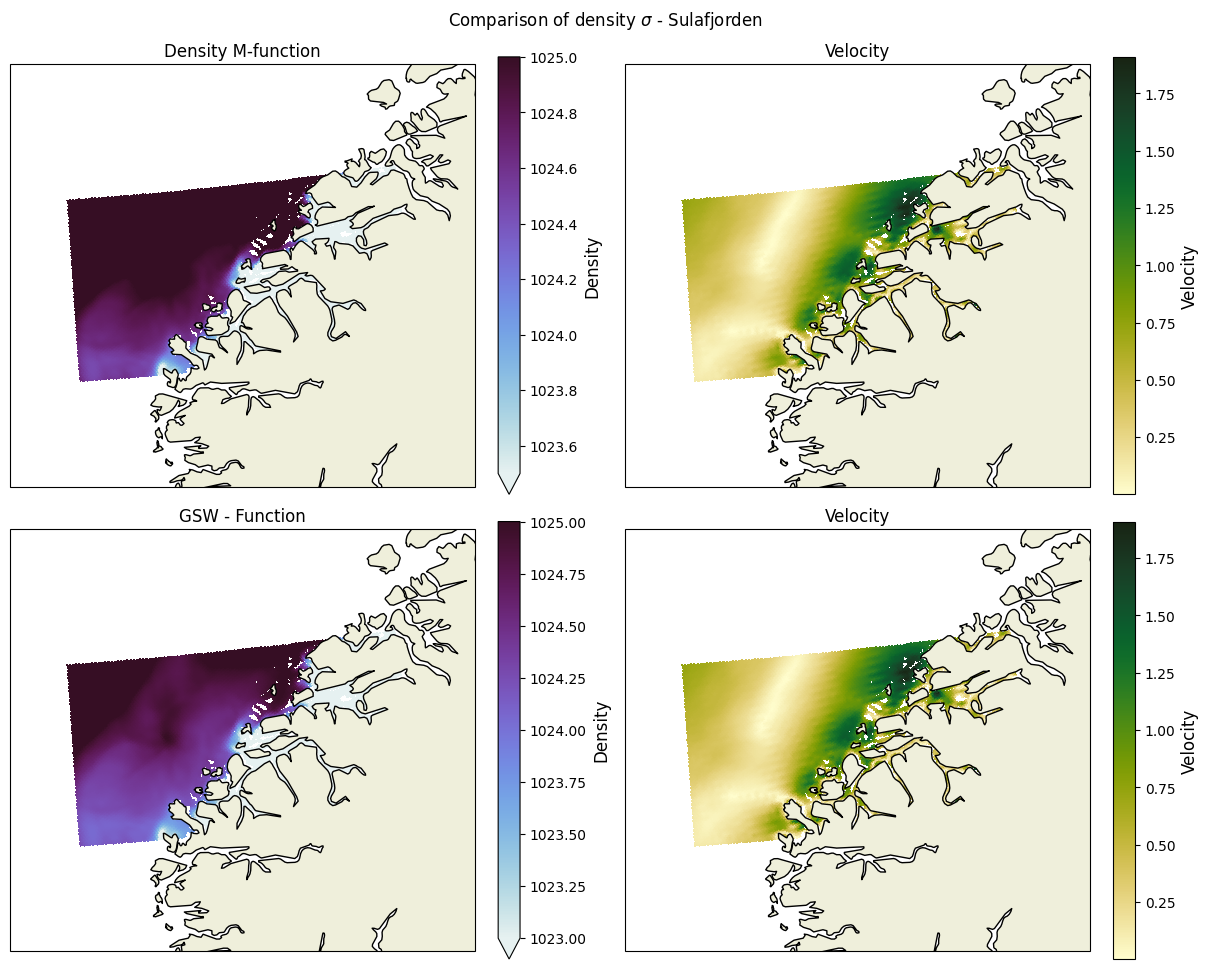

In [34]:
#Make plot of Skagerak + of northerner areas to examine whether the field looks plausible or not and compared to velocity field (focusing on fronts)

"""SULAFJORDEN"""

fig, axes = plt.subplots(2,2, figsize = (12, 10), layout = 'compressed', subplot_kw= {'projection' : ccrs.NorthPolarStereo()})

#Own function
my_density = axes[0][0]
im1 = my_density.pcolormesh(sulafjorden.lon,sulafjorden.lat, density_field_sul, cmap = cmocean.cm.dense, transform = ccrs.PlateCarree(), vmin = 1023.5, vmax = 1025)
my_density.set_title(f'Density M-function') 
my_density.add_feature(cartopy.feature.LAND, zorder = 1, edgecolor = "black")
cbar1 = fig.colorbar(im1, ax=my_density, orientation = 'vertical' , extend = 'min')
cbar1.set_label('Density', fontsize = 12)

#GSW function
norkyst_velocity = axes[0][1]
u,v =sulafjorden['u_eastward'].values,sulafjorden['Vwind_northward'].values
mean_vel = np.sqrt(u**2 + v**2)
im2 = norkyst_velocity.pcolormesh(sulafjorden.lon,sulafjorden.lat, mean_vel , cmap = cmocean.cm.speed, transform = ccrs.PlateCarree())
norkyst_velocity.set_title(f'Velocity') 
norkyst_velocity.add_feature(cartopy.feature.LAND, zorder = 1, edgecolor = "black")
cbar2 = fig.colorbar(im2, ax=norkyst_velocity, orientation = 'vertical')
cbar2.set_label('Velocity', fontsize = 12)

#diff
gsw_density = axes[1][0]
im3 = gsw_density.pcolormesh(sulafjorden.lon,sulafjorden.lat, density_avg_gsw_sul, cmap = cmocean.cm.dense, transform = ccrs.PlateCarree(), vmin = 1023, vmax = 1025)
gsw_density.set_title(f'GSW - Function') 
gsw_density.add_feature(cartopy.feature.LAND, zorder = 1, edgecolor = "black")
cbar2 = fig.colorbar(im3, ax=gsw_density, orientation = 'vertical', extend = 'min')
cbar2.set_label('Density', fontsize = 12)

#diff
norkyst_velocity2 = axes[1][1]
im4 = norkyst_velocity2.pcolormesh(sulafjorden.lon,sulafjorden.lat, mean_vel, cmap = cmocean.cm.speed, transform = ccrs.PlateCarree())
norkyst_velocity2.set_title(f'Velocity') 
norkyst_velocity2.add_feature(cartopy.feature.LAND, zorder = 1, edgecolor = "black")
cbar2 = fig.colorbar(im4, ax=norkyst_velocity2, orientation = 'vertical')
cbar2.set_label('Velocity', fontsize = 12)

for ax in [my_density, norkyst_velocity, gsw_density, norkyst_velocity2]:
    ax.set_ylabel('Latitude')
    ax.set_xlabel('Longitude')
    
plt.suptitle(r'Comparison of density $\sigma$ - Sulafjorden')
plt.show()
